# Graph Laplacian: Why It Matters

The graph Laplacian is central to clustering, diffusion, graph signal processing, and spectral embeddings.
Given weighted adjacency $W$ and degree matrix $D$, the combinatorial Laplacian is
$$
L = D - W.
$$
Its eigenvectors reveal low-frequency graph geometry and community structure.


## Build a graph and inspect Laplacian spectrum


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path("python/graph-laplacian"); OUT.mkdir(parents=True, exist_ok=True)
n = 120
X = np.r_[rng.normal(loc=-1.0, scale=0.32, size=(n//2, 2)),
          rng.normal(loc=1.0, scale=0.35, size=(n-n//2, 2))]

d2 = np.sum((X[:,None,:] - X[None,:,:])**2, axis=2)
k = 10
idx = np.argsort(d2, axis=1)[:, 1:k+1]
W = np.zeros((n, n))
for i in range(n):
    W[i, idx[i]] = np.exp(-d2[i, idx[i]] / 0.45)
W = np.maximum(W, W.T)
D = np.diag(W.sum(axis=1))
L = D - W
ev, U = np.linalg.eigh(L)


## Fiedler vector and low-frequency spectrum


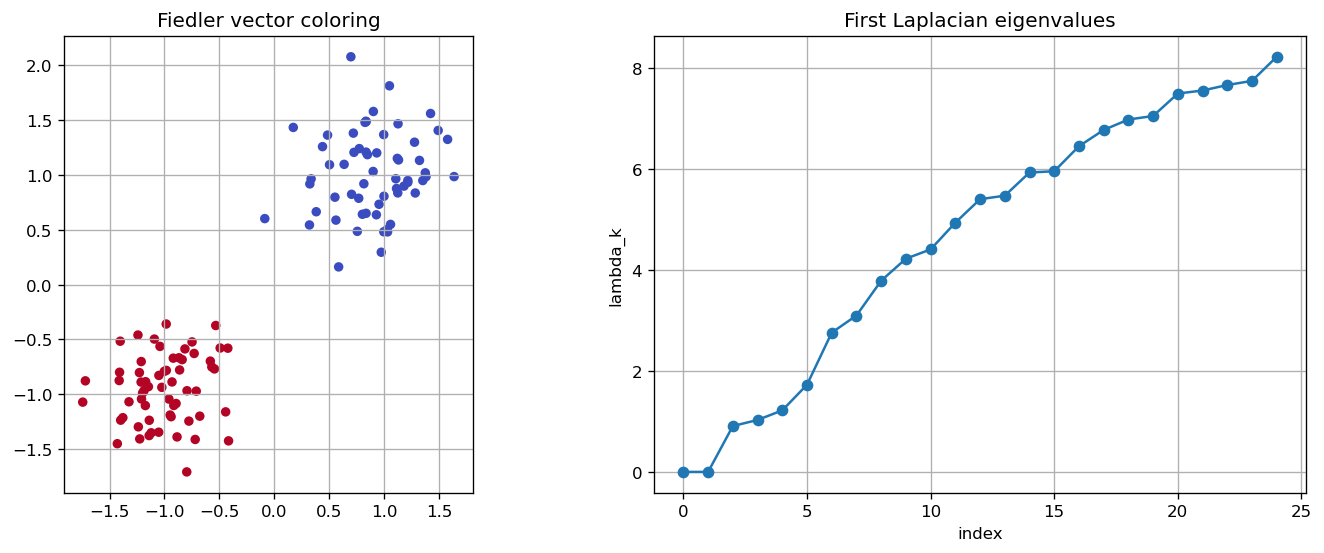

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
axes[0].scatter(X[:,0], X[:,1], c=U[:,1], cmap="coolwarm", s=22)
axes[0].set_title("Fiedler vector coloring")
axes[0].set_aspect("equal")
axes[1].plot(ev[:25], "o-", lw=1.5)
axes[1].set_title("First Laplacian eigenvalues")
axes[1].set_xlabel("index")
axes[1].set_ylabel("lambda_k")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
